In [7]:
# Basic libraries
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Deep learning & preprocessing
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, EfficientNetB0, InceptionV3
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


In [12]:
DATASETS = {
    "train": "train/",
    "test": "test/"
}

In [13]:
#Make sure that the same classes exist in both dataset
train_classes = sorted(os.listdir(DATASETS["train"]))
test_classes  = sorted(os.listdir(DATASETS["test"]))

print("Train classes:", train_classes)
print("Test classes:", test_classes)

assert train_classes == test_classes, "❌ Train/Test classes are NOT identical"
print("✅ Train and Test classes are identical")


Train classes: ['Class_A', 'Class_B', 'Class_C', 'Class_D', 'Class_E', 'Class_F', 'Class_G', 'Class_H', 'Class_I', 'Class_J', 'Class_K', 'Class_L', 'Class_M', 'Class_N', 'Class_O', 'Class_P', 'Class_Q', 'Class_R', 'Class_S', 'Class_T', 'Class_U', 'Class_V', 'Class_W', 'Class_X', 'Class_Y', 'Class_Z']
Test classes: ['Class_A', 'Class_B', 'Class_C', 'Class_D', 'Class_E', 'Class_F', 'Class_G', 'Class_H', 'Class_I', 'Class_J', 'Class_K', 'Class_L', 'Class_M', 'Class_N', 'Class_O', 'Class_P', 'Class_Q', 'Class_R', 'Class_S', 'Class_T', 'Class_U', 'Class_V', 'Class_W', 'Class_X', 'Class_Y', 'Class_Z']
✅ Train and Test classes are identical


In [14]:
train_set = set(train_classes)
test_set  = set(test_classes)

print("Only in train:", train_set - test_set)
print("Only in test:", test_set - train_set)


Only in train: set()
Only in test: set()


In [7]:
import shutil
import os

REMOVE_CLASSES = [
    "Class_Nothing", "Class_nothing",
    "Class_Space", "Class_space"
]

def remove_classes(base_dir, remove_list):
    for cls in os.listdir(base_dir):
        if cls in remove_list:
            path = os.path.join(base_dir, cls)
            print(f"Removing: {path}")
            shutil.rmtree(path)

remove_classes("train/", REMOVE_CLASSES)
remove_classes("test/", REMOVE_CLASSES)


Removing: train/Class_Nothing
Removing: train/Class_Space
Removing: test/Class_nothing
Removing: test/Class_space


In [10]:
train_classes = sorted(os.listdir("train/"))
test_classes  = sorted(os.listdir("test/"))

print(train_classes)
print(test_classes)

assert train_classes == test_classes
print("✅ Classes are now identical and clean")


['.ipynb_checkpoints', 'Class_A', 'Class_B', 'Class_C', 'Class_D', 'Class_E', 'Class_F', 'Class_G', 'Class_H', 'Class_I', 'Class_J', 'Class_K', 'Class_L', 'Class_M', 'Class_N', 'Class_O', 'Class_P', 'Class_Q', 'Class_R', 'Class_S', 'Class_T', 'Class_U', 'Class_V', 'Class_W', 'Class_X', 'Class_Y', 'Class_Z']
['.ipynb_checkpoints', 'Class_A', 'Class_B', 'Class_C', 'Class_D', 'Class_E', 'Class_F', 'Class_G', 'Class_H', 'Class_I', 'Class_J', 'Class_K', 'Class_L', 'Class_M', 'Class_N', 'Class_O', 'Class_P', 'Class_Q', 'Class_R', 'Class_S', 'Class_T', 'Class_U', 'Class_V', 'Class_W', 'Class_X', 'Class_Y', 'Class_Z']
✅ Classes are now identical and clean


In [11]:
#.ipynb_checkpoints
import shutil
import os

for split in ["train/", "test/"]:
    checkpoint_path = os.path.join(split, ".ipynb_checkpoints")
    if os.path.exists(checkpoint_path):
        shutil.rmtree(checkpoint_path)
        print(f"Removed {checkpoint_path}")


Removed train/.ipynb_checkpoints
Removed test/.ipynb_checkpoints


In [13]:
train_classes = sorted(os.listdir("train/"))
test_classes  = sorted(os.listdir("test/"))

print(len(train_classes), train_classes)
print(len(test_classes), test_classes)

assert train_classes == test_classes


26 ['Class_A', 'Class_B', 'Class_C', 'Class_D', 'Class_E', 'Class_F', 'Class_G', 'Class_H', 'Class_I', 'Class_J', 'Class_K', 'Class_L', 'Class_M', 'Class_N', 'Class_O', 'Class_P', 'Class_Q', 'Class_R', 'Class_S', 'Class_T', 'Class_U', 'Class_V', 'Class_W', 'Class_X', 'Class_Y', 'Class_Z']
26 ['Class_A', 'Class_B', 'Class_C', 'Class_D', 'Class_E', 'Class_F', 'Class_G', 'Class_H', 'Class_I', 'Class_J', 'Class_K', 'Class_L', 'Class_M', 'Class_N', 'Class_O', 'Class_P', 'Class_Q', 'Class_R', 'Class_S', 'Class_T', 'Class_U', 'Class_V', 'Class_W', 'Class_X', 'Class_Y', 'Class_Z']


## ⏭️ Next Stage: Preprocessing & Generators 

- Image size standardization  
- Normalization  
- Data augmentation  
- Proper label preparation  


In [17]:
## 1️⃣ Define the General Settings
#> Suitable for **ResNet** & **EfficientNet**

IMG_SIZE = 224         
BATCH_SIZE = 32
NUM_CLASSES = 26

TRAIN_DIR = "train/"
TEST_DIR  = "test/"


In [18]:
#2️⃣ Data Augmentation (Train)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)


In [19]:
## 3️⃣ Test Generator (No Augmentation )

test_datagen = ImageDataGenerator(rescale=1./255)


In [20]:
## 4️⃣ Creating Generators

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 10114 images belonging to 26 classes.
Found 253 images belonging to 26 classes.


# Using Part of the Training Set as a Validation Set

Instead of relying only on **253 images** in the test set,  
we can split a portion of the training data (e.g., **10–20%**) as a validation set.

- **Train** → 36,019 images  
- **Validation** → 3,600–7,200 images  
- **Test** → 253 images *(used for final evaluation only)*


In [22]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.1   
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    subset='validation'
)


Found 9126 images belonging to 26 classes.
Found 988 images belonging to 26 classes.


### ➕ Adding Validation Split

We will update **Steps 2, 3, and 4** after this point  
to include a **validation split** in the data generators.


In [23]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.1   
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    subset='training'      
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    subset='validation'    
)


test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 9126 images belonging to 26 classes.
Found 988 images belonging to 26 classes.
Found 253 images belonging to 26 classes.


- **Train:** 32,432 images (90% of the original train set)  
- **Validation:** 3,587 images (10% of the original train set)  
- **Test:** 253 images


In [20]:
## 5️⃣ Verify the Labels

print("Class indices:")
print(train_generator.class_indices)


Class indices:
{'Class_A': 0, 'Class_B': 1, 'Class_C': 2, 'Class_D': 3, 'Class_E': 4, 'Class_F': 5, 'Class_G': 6, 'Class_H': 7, 'Class_I': 8, 'Class_J': 9, 'Class_K': 10, 'Class_L': 11, 'Class_M': 12, 'Class_N': 13, 'Class_O': 14, 'Class_P': 15, 'Class_Q': 16, 'Class_R': 17, 'Class_S': 18, 'Class_T': 19, 'Class_U': 20, 'Class_V': 21, 'Class_W': 22, 'Class_X': 23, 'Class_Y': 24, 'Class_Z': 25}


Images batch shape: (32, 224, 224, 3)
Labels batch shape: (32, 26)


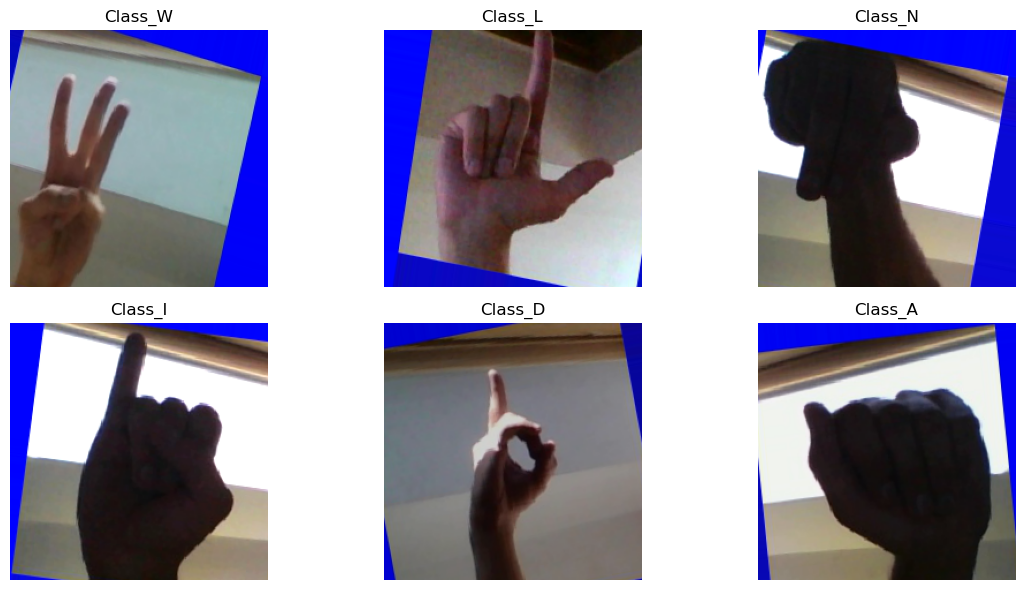

In [21]:
## 6️⃣ Quick Test (Batch Preview)


images, labels = next(train_generator)

print("Images batch shape:", images.shape)  # (batch_size, IMG_SIZE, IMG_SIZE, 3)

print("Labels batch shape:", labels.shape)  # (batch_size, NUM_CLASSES)

### Display the First 6 Images with Labels
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    label_index = np.argmax(labels[i])
    
    class_name = [k for k,v in train_generator.class_indices.items() if v==label_index][0]
    plt.title(class_name)
    plt.axis("off")
plt.tight_layout()
plt.show()


## 🔹 1️⃣ Create a Simple Model

# **Baseline CNN**

In [ ]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


In [23]:


history = model.fit(
    train_generator,
    epochs=3,              
    validation_data=val_generator
)


Epoch 1/3
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 622s 612ms/step - accuracy: 0.1418 - loss: 2.8251 - val_accuracy: 0.2275 - val_loss: 2.4681
Epoch 2/3
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 573s 565ms/step - accuracy: 0.3571 - loss: 1.9227 - val_accuracy: 0.3340 - val_loss: 1.9271
Epoch 3/3
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 577s 569ms/step - accuracy: 0.4620 - loss: 1.5583 - val_accuracy: 0.3981 - val_loss: 1.7249


In [24]:

loss, acc = model.evaluate(test_generator)
print(f"Test Accuracy: {acc*100:.2f}%")


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.6640 - loss: 1.0626 
Test Accuracy: 66.40%


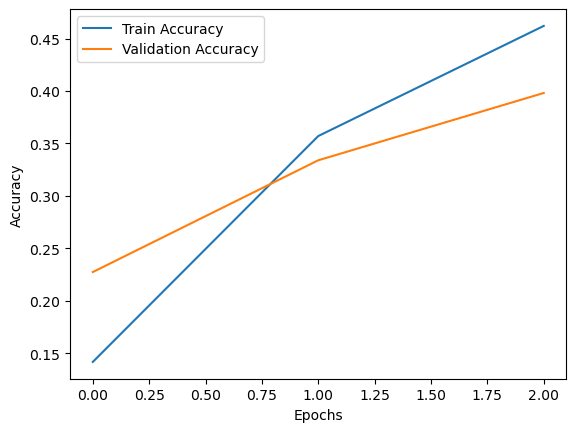

In [25]:


import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


### ✅ Recommended Order (From Easiest → Hardest/Strongest)

- **VGG16 / VGG19** → Excellent starting point, fast and straightforward.  
- **ResNet50** → A stronger step after VGG, better performance.  
- **InceptionV3** → More complex, requires careful training.  

## Step 1: VGG16 / VGG19 (The Beginning)

**Goal:** Understand **Transfer Learning** and **Fine-tuning** easily.

**Load the Model:**


In [26]:

from keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 32s 1us/step


## Step 2: Add New Dense Layers for Your Classification


In [28]:
## Step 2: Add New Dense Layers for Your Classification

from keras.models import Sequential
from keras.layers import Flatten, Dense, Dropout
num_classes = 26  # عددي الفئات اللي عندك

model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])


## Step 3: Freeze the Base Layers


In [29]:

for layer in base_model.layers:
    layer.trainable = False


## Step 4: Compile and Train


In [31]:

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)


Epoch 1/5
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 1684s 2s/step - accuracy: 0.0814 - loss: 2.9992 - val_accuracy: 0.1257 - val_loss: 2.7556
Epoch 2/5
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 2383s 2s/step - accuracy: 0.0942 - loss: 2.8621 - val_accuracy: 0.1583 - val_loss: 2.6381
Epoch 3/5
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 2627s 3s/step - accuracy: 0.1018 - loss: 2.8300 - val_accuracy: 0.1650 - val_loss: 2.6941
Epoch 4/5
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 2663s 3s/step - accuracy: 0.1052 - loss: 2.8127 - val_accuracy: 0.1965 - val_loss: 2.5625
Epoch 5/5
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 2665s 3s/step - accuracy: 0.1088 - loss: 2.8067 - val_accuracy: 0.1818 - val_loss: 2.5233


In [ ]:
for layer in base_model.layers[-4:]:
    layer.trainable = True


# 🔍 Diagnosing and Fixing Low Model Accuracy


In [32]:
import os
import pandas as pd

def count_images_per_class(folder_path):
    class_counts = {}
    
    for class_name in sorted(os.listdir(folder_path)):
        class_path = os.path.join(folder_path, class_name)
        
        if os.path.isdir(class_path):
            images = [
                img for img in os.listdir(class_path)
                if img.lower().endswith(('.png', '.jpg', '.jpeg'))
            ]
            class_counts[class_name] = len(images)
    
    return class_counts



train_path = "train/"
test_path  = "test/"

train_counts = count_images_per_class(train_path)
test_counts  = count_images_per_class(test_path c


df = pd.DataFrame({
    "Train Images": train_counts,
    "Test Images": test_counts
}).fillna(0).astype(int)


df["Equal?"] = df["Train Images"] == df["Test Images"]

df

,Train Images,Test Images,Equal?
Class_A,1526,10,False
Class_B,1517,10,False
Class_C,1523,10,False
Class_D,389,10,False
Class_E,1520,10,False
Class_F,1553,10,False
Class_G,1529,10,False
Class_H,1510,10,False
Class_I,1508,10,False
Class_J,1515,10,False


In [ ]:
import os
import random
import shutil

TARGET_COUNT = 389
dataset_path = "train/"

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    images = os.listdir(class_path)

    if len(images) > TARGET_COUNT:
        images_to_keep = random.sample(images, TARGET_COUNT)
        
        for img in images:
            if img not in images_to_keep:
                os.remove(os.path.join(class_path, img))


In [ ]:
import os
import pandas as pd

train_path = "train/"

data = []

for class_name in sorted(os.listdir(train_path)):
    class_path = os.path.join(train_path, class_name)
    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        data.append([class_name, count])

df = pd.DataFrame(data, columns=["Class", "Train Images"])
df


In [ ]:
df["Equal"] = df["Train Images"] == df["Train Images"].iloc[0]
df


In [49]:
import os
class_z_path = "train/Class_Z/"
print(class_z_path)
print(len(os.listdir(class_z_path)))


train/Class_Z/
480


In [51]:
import os
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img, img_to_array, save_img

train_path = "train/"    
TARGET = 389            


In [52]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)


In [53]:
for class_name in sorted(os.listdir(train_path)):
    class_path = os.path.join(train_path, class_name)
    images = os.listdir(class_path)

    current_count = len(images)

    if current_count >= TARGET:
        continue   # الكلاس تمام

    needed = TARGET - current_count
    print(f"{class_name}: generating {needed} images")

    i = 0
    while current_count < TARGET:
        img = load_img(os.path.join(class_path, images[i % len(images)]))
        x = img_to_array(img)
        x = datagen.random_transform(x)

        save_img(
            os.path.join(class_path, f"aug_{current_count}.jpg"),
            x
        )

        current_count += 1
        i += 1


In [54]:
data = []

for class_name in sorted(os.listdir(train_path)):
    count = len(os.listdir(os.path.join(train_path, class_name)))
    data.append([class_name, count])

df = pd.DataFrame(data, columns=["Class", "Train Images"])
df["Equal"] = df["Train Images"] == df["Train Images"].iloc[0]
df


,Class,Train Images,Equal
0,Class_A,389,True
1,Class_B,389,True
2,Class_C,389,True
3,Class_D,389,True
4,Class_E,389,True
5,Class_F,389,True
6,Class_G,389,True
7,Class_H,389,True
8,Class_I,389,True
9,Class_J,389,True


In [55]:
import os
import random

class_z_path = "train/Class_Z/"
images = os.listdir(class_z_path)

TARGET = 389

if len(images) > TARGET:
    images_to_remove = random.sample(images, len(images) - TARGET)
    for img in images_to_remove:
        os.remove(os.path.join(class_z_path, img))
    print(f"Class_Z reduced to {TARGET} images")
else:
    print("Class_Z already <= TARGET")


Class_Z reduced to 389 images


In [56]:
len(os.listdir("train/Class_Z"))


389

In [57]:
# إعادة الجدول النهائي
import pandas as pd

train_path = "train/"
data = []

for class_name in sorted(os.listdir(train_path)):
    count = len(os.listdir(os.path.join(train_path, class_name)))
    data.append([class_name, count])

df = pd.DataFrame(data, columns=["Class", "Train Images"])
df["Equal"] = df["Train Images"] == df["Train Images"].iloc[0]
df


,Class,Train Images,Equal
0,Class_A,389,True
1,Class_B,389,True
2,Class_C,389,True
3,Class_D,389,True
4,Class_E,389,True
5,Class_F,389,True
6,Class_G,389,True
7,Class_H,389,True
8,Class_I,389,True
9,Class_J,389,True


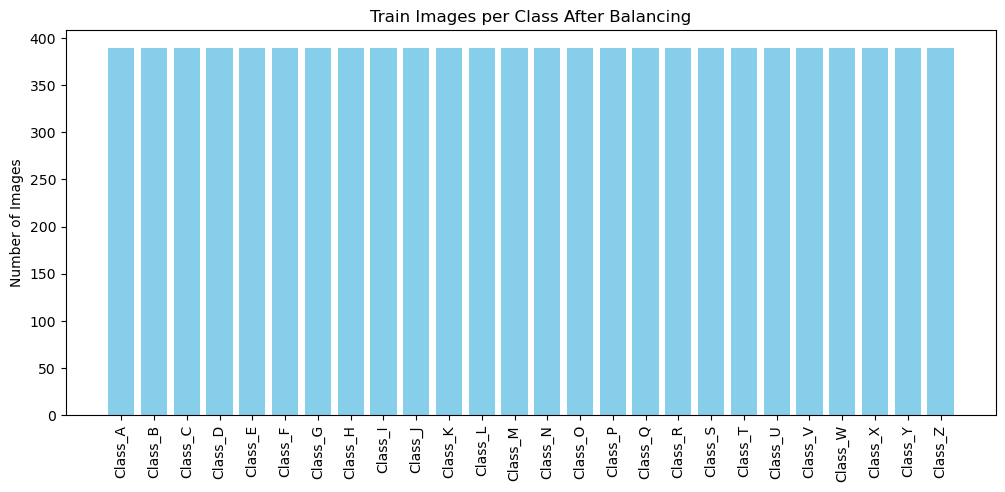

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.bar(df["Class"], df["Train Images"], color='skyblue')
plt.xticks(rotation=90)
plt.ylabel("Number of Images")
plt.title("Train Images per Class After Balancing")
plt.show()


# 1) VGG16 

In [32]:
# -------------------------
# 1️⃣ Data Generators
# -------------------------
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 26

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)


In [33]:
# -------------------------
# 2️⃣ Base Model (VGG16 or VGG19)
# -------------------------
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE,3))
# إذا حابة تجربي VGG19
# base_model = VGG19(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE,3))

# Freeze the base layers
for layer in base_model.layers:
    layer.trainable = False

In [34]:
# -------------------------
# 3️⃣ إضافة طبقات Dense
# -------------------------
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

In [35]:

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 26)             │         6,682 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,144,154 (80.66 MB)

 Trainable params: 6,429,466 (24.53 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [36]:
train_generator = train_datagen.flow_from_directory(
    'train',                 
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    'test',                 
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 10114 images belonging to 26 classes.
Found 253 images belonging to 26 classes.


In [66]:
# -------------------------
# 4️⃣ Train (Epochs قليلة للتأكد من الداتا)
# -------------------------
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=3   # بس للتأكد من الداتا شغالة
)

Epoch 1/3
317/317 ━━━━━━━━━━━━━━━━━━━━ 1674s 5s/step - accuracy: 0.1960 - loss: 2.8231 - val_accuracy: 0.4980 - val_loss: 2.0453
Epoch 2/3
317/317 ━━━━━━━━━━━━━━━━━━━━ 812s 3s/step - accuracy: 0.4202 - loss: 2.0615 - val_accuracy: 0.6680 - val_loss: 1.4903
Epoch 3/3
317/317 ━━━━━━━━━━━━━━━━━━━━ 759s 2s/step - accuracy: 0.5234 - loss: 1.6775 - val_accuracy: 0.7233 - val_loss: 1.1760


In [67]:

# -------------------------
# 5️⃣ Evaluation على Test
# -------------------------
loss, acc = model.evaluate(test_generator)
print(f"Test Accuracy: {acc*100:.2f}%")


8/8 ━━━━━━━━━━━━━━━━━━━━ 45s 6s/step - accuracy: 0.7233 - loss: 1.1760
Test Accuracy: 72.33%


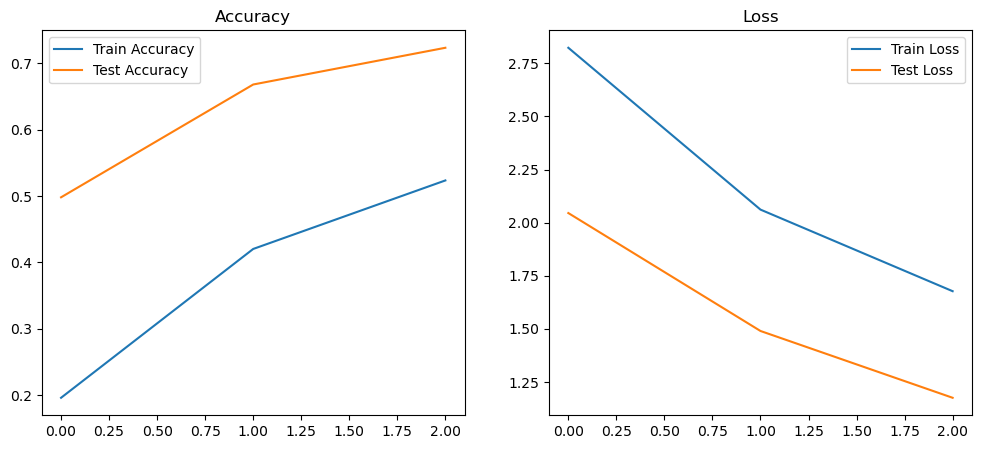

In [68]:
# -------------------------
# 6️⃣ رسم Accuracy / Loss
# -------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [37]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 26

# Train DataGenerator مع augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Test DataGenerator بدون augmentation
test_datagen = ImageDataGenerator(rescale=1./255)

# Train generator
train_generator = train_datagen.flow_from_directory(
    'train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Test generator
test_generator = test_datagen.flow_from_directory(
    'test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 10114 images belonging to 26 classes.
Found 253 images belonging to 26 classes.


In [38]:
# -------------------------
# 2️⃣ إنشاء Base Model (VGG16 أو VGG19)
# -------------------------
from tensorflow.keras.applications import VGG16, VGG19
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Base Model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE,3))
# لو حابة VGG19 بدلها:
# base_model = VGG19(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE,3))

# Freeze كل الطبقات الأساسية
for layer in base_model.layers:
    layer.trainable = False

In [39]:
# -------------------------
# 3️⃣ إضافة طبقات Dense للتصنيف
# -------------------------
model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 26)             │        13,338 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,573,594 (105.18 MB)

 Trainable params: 12,858,906 (49.05 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [73]:
# -------------------------
# 4️⃣ Training المرحلة الأولى (Freeze Base Layers)
# -------------------------
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10
)


Epoch 1/10
317/317 ━━━━━━━━━━━━━━━━━━━━ 1665s 5s/step - accuracy: 0.2405 - loss: 2.6926 - val_accuracy: 0.5731 - val_loss: 1.8598
Epoch 2/10
317/317 ━━━━━━━━━━━━━━━━━━━━ 819s 3s/step - accuracy: 0.4882 - loss: 1.8311 - val_accuracy: 0.6917 - val_loss: 1.2450
Epoch 3/10
317/317 ━━━━━━━━━━━━━━━━━━━━ 796s 3s/step - accuracy: 0.5961 - loss: 1.4275 - val_accuracy: 0.8063 - val_loss: 0.9600
Epoch 4/10
317/317 ━━━━━━━━━━━━━━━━━━━━ 12249s 39s/step - accuracy: 0.6588 - loss: 1.1835 - val_accuracy: 0.8340 - val_loss: 0.7755
Epoch 5/10
317/317 ━━━━━━━━━━━━━━━━━━━━ 51265s 162s/step - accuracy: 0.7032 - loss: 1.0403 - val_accuracy: 0.8538 - val_loss: 0.6707
Epoch 6/10
317/317 ━━━━━━━━━━━━━━━━━━━━ 888s 3s/step - accuracy: 0.7379 - loss: 0.9003 - val_accuracy: 0.8814 - val_loss: 0.5965
Epoch 7/10
317/317 ━━━━━━━━━━━━━━━━━━━━ 747s 2s/step - accuracy: 0.7615 - loss: 0.8177 - val_accuracy: 0.8854 - val_loss: 0.5127
Epoch 8/10
317/317 ━━━━━━━━━━━━━━━━━━━━ 780s 2s/step - accuracy: 0.7822 - loss: 0.7447 - 

In [40]:
val_generator

In [41]:
train_generator = train_datagen.flow_from_directory(
    'train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    'train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    subset='validation'
)


Found 10114 images belonging to 26 classes.
Found 0 images belonging to 26 classes.


In [42]:
import os
os.path.exists("train/Class_A/A100.jpg")


False

In [43]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.1  
)


In [44]:
train_generator = train_datagen.flow_from_directory(
    'train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    subset='training'  
)

val_generator = train_datagen.flow_from_directory(
    'train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    subset='validation' 
)


Found 9126 images belonging to 26 classes.
Found 988 images belonging to 26 classes.


In [81]:
# -------------------------
# 5️⃣ Fine-tuning (فتح آخر طبقات Base Model)
# -------------------------
for layer in base_model.layers[-4:]:
    layer.trainable = True

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_ft = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)


Epoch 1/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 896s 3s/step - accuracy: 0.9131 - loss: 0.2836 - val_accuracy: 0.8735 - val_loss: 0.3673
Epoch 2/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 1122s 4s/step - accuracy: 0.9268 - loss: 0.2253 - val_accuracy: 0.8907 - val_loss: 0.3428
Epoch 3/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 2016s 7s/step - accuracy: 0.9333 - loss: 0.2044 - val_accuracy: 0.8745 - val_loss: 0.3811
Epoch 4/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 1022s 4s/step - accuracy: 0.9473 - loss: 0.1676 - val_accuracy: 0.8816 - val_loss: 0.3400
Epoch 5/5
286/286 ━━━━━━━━━━━━━━━━━━━━ 939s 3s/step - accuracy: 0.9486 - loss: 0.1557 - val_accuracy: 0.8978 - val_loss: 0.3165


In [45]:
# -------------------------
# 6️⃣ Evaluation على Test Set
# -------------------------
loss, acc = model.evaluate(test_generator)
print(f"Test Accuracy: {acc*100:.2f}%")

8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.0356 - loss: 3.4924    
Test Accuracy: 3.56%


In [46]:
loss, acc = model.evaluate(val_generator)
print(f"Validation Accuracy (clean): {acc*100:.2f}%")


31/31 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - accuracy: 0.0354 - loss: 3.5358     
Validation Accuracy (clean): 3.54%


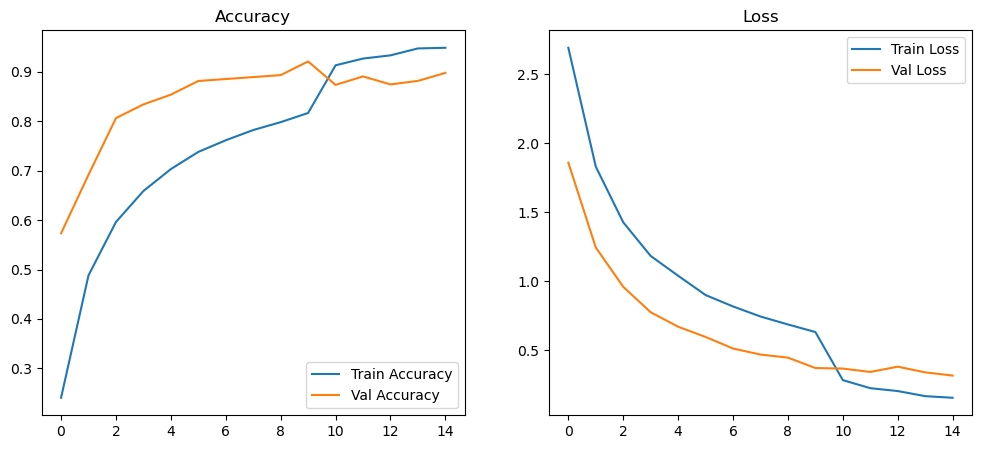

In [84]:
# -------------------------
# 7️⃣ رسم الأداء
# -------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'] + history_ft.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'] + history_ft.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'] + history_ft.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'] + history_ft.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step


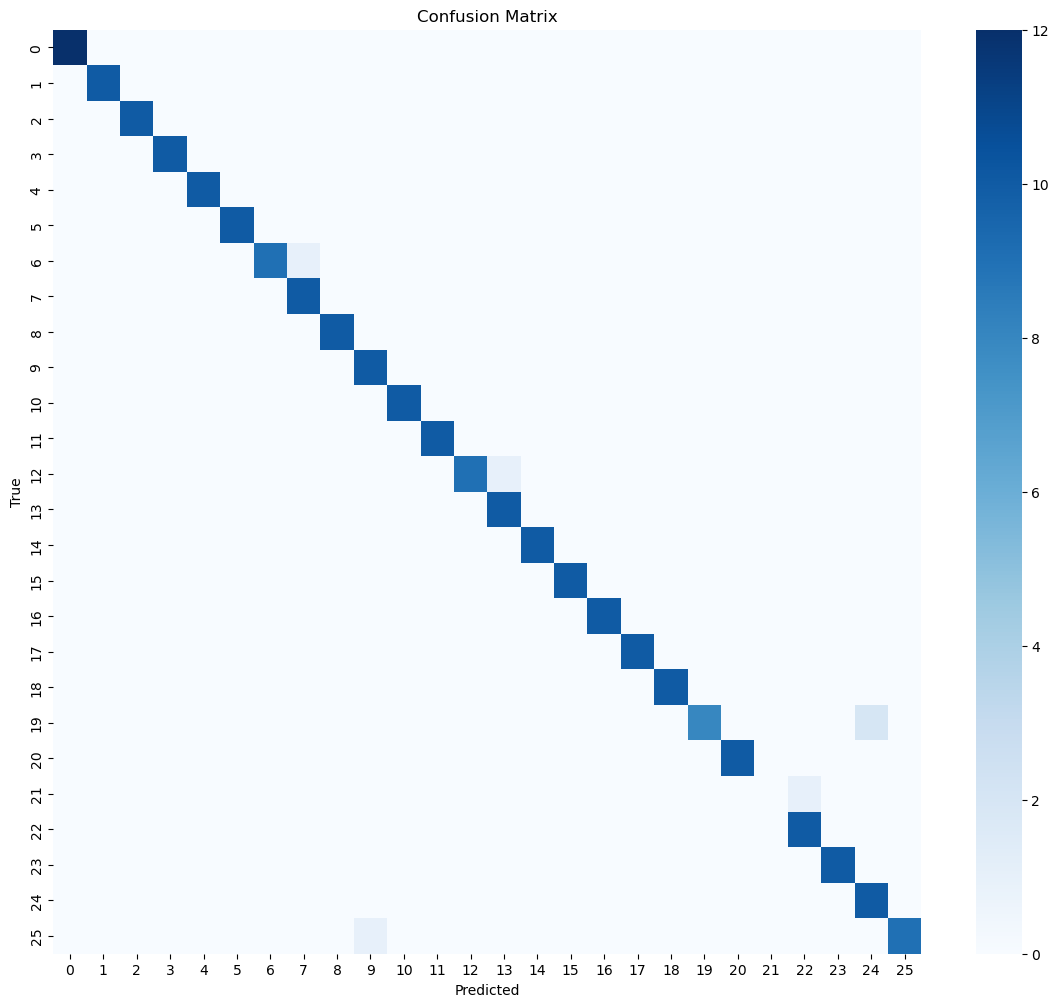

In [85]:
#🔹 Confusion Matrix
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(14,12))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [86]:
#🔹 Classification Report
test_generator.reset()

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes


8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step


In [88]:
from keras.saving import save_model
save_model(model, 'my_model.keras')


In [50]:
import numpy as np
from sklearn.metrics import accuracy_score

# Predict
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f"Accuracy: {accuracy*100:.2f}%")


8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step
Accuracy: 92.89%


# 2)ResNet50

In [47]:
from keras.models import load_model
model = load_model('my_model.keras')
model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])


C:\Users\Rahma mohamed\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [48]:
#2️⃣ Freeze Base Layers 
for layer in model.layers[:-5]:  ## Assume Fine-tuning the Last 3–5 Layers

    layer.trainable = False


In [49]:
# 3️⃣ Training على الـ Head فقط
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_head = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,   
    callbacks=[early_stop]
)


Epoch 1/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 888s 3s/step - accuracy: 0.0528 - loss: 10.6836 - val_accuracy: 0.0648 - val_loss: 3.1692
Epoch 2/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 862s 3s/step - accuracy: 0.1853 - loss: 2.7854 - val_accuracy: 0.3401 - val_loss: 2.1814
Epoch 3/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 844s 3s/step - accuracy: 0.5536 - loss: 1.4803 - val_accuracy: 0.6296 - val_loss: 1.0930
Epoch 4/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 875s 3s/step - accuracy: 0.7514 - loss: 0.8376 - val_accuracy: 0.7126 - val_loss: 1.0697
Epoch 5/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 866s 3s/step - accuracy: 0.8413 - loss: 0.6103 - val_accuracy: 0.7955 - val_loss: 0.7857
Epoch 6/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 884s 3s/step - accuracy: 0.8777 - loss: 0.5585 - val_accuracy: 0.7763 - val_loss: 1.0328
Epoch 7/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 924s 3s/step - accuracy: 0.8874 - loss: 0.5833 - val_accuracy: 0.7824 - val_loss: 1.2687
Epoch 8/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 928s 3s/step - accuracy: 0.8978 - loss: 0.5427 - val_acc

In [52]:
## 4️⃣ Partial Fine-tuning of the Base Model

#- Unfreeze the last 3–5 layers of the Base Model

from keras.optimizers import SGD

#Unfreeze the last 3–5 layers of the Base Model
for layer in model.layers[-5:]:
    layer.trainable = True

model.compile(
    optimizer=SGD(learning_rate=1e-5, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ft = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,          # عدد آمن
    callbacks=[early_stop]
)


Epoch 1/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 919s 3s/step - accuracy: 0.9133 - loss: 0.3105 - val_accuracy: 0.8360 - val_loss: 0.5889
Epoch 2/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 925s 3s/step - accuracy: 0.9224 - loss: 0.2663 - val_accuracy: 0.8209 - val_loss: 0.5808
Epoch 3/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 921s 3s/step - accuracy: 0.9223 - loss: 0.2665 - val_accuracy: 0.8077 - val_loss: 0.6343
Epoch 4/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 925s 3s/step - accuracy: 0.9293 - loss: 0.2303 - val_accuracy: 0.8259 - val_loss: 0.5996
Epoch 5/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 925s 3s/step - accuracy: 0.9318 - loss: 0.2239 - val_accuracy: 0.8300 - val_loss: 0.5840
Epoch 6/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 902s 3s/step - accuracy: 0.9300 - loss: 0.2187 - val_accuracy: 0.8381 - val_loss: 0.5156
Epoch 7/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 1721s 6s/step - accuracy: 0.9335 - loss: 0.2234 - val_accuracy: 0.8320 - val_loss: 0.5983
Epoch 8/10
121/286 ━━━━━━━━━━━━━━━━━━━━ 17:45 6s/step - accuracy: 0.9452 - loss: 0.1798

KeyboardInterrupt: 

In [53]:
model.save('my_model_finetuned.keras')


In [ ]:
## 5️⃣ Final Evaluation on the Test Generator
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)


In [54]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)


8/8 ━━━━━━━━━━━━━━━━━━━━ 43s 5s/step - accuracy: 0.9526 - loss: 0.2012
Test Accuracy: 0.9525691866874695


# Comparison


In [57]:
from keras.models import load_model

## Previous Model

old_model = load_model('my_model.keras')

## New Model After Fine-tuning

new_model = load_model('my_model_finetuned.keras')


C:\Users\Rahma mohamed\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [58]:
old_loss, old_acc = old_model.evaluate(test_generator)
new_loss, new_acc = new_model.evaluate(test_generator)

print("Old Model Test Accuracy:", old_acc)
print("New Model Test Accuracy:", new_acc)


8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9763 - loss: 0.0742
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9526 - loss: 0.2012
Old Model Test Accuracy: 0.9762845635414124
New Model Test Accuracy: 0.9525691866874695


**Why is the old model performing better?**

Fine-tuning improved the internal representations but did **not generalize better** on the Test Set.


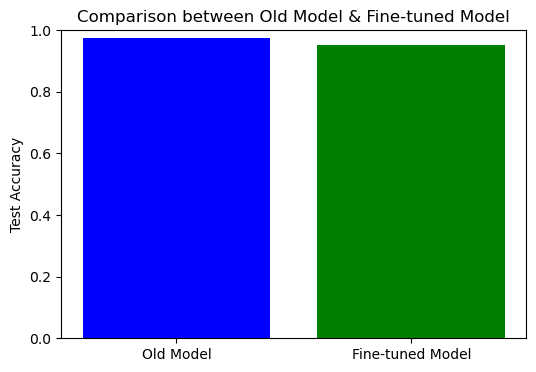

In [59]:
import matplotlib.pyplot as plt

models = ['Old Model', 'Fine-tuned Model']
accuracies = [old_acc, new_acc]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies, color=['blue', 'green'])
plt.ylim(0,1)
plt.ylabel('Test Accuracy')
plt.title('Comparison between Old Model & Fine-tuned Model')
plt.show()


In [60]:
print(test_generator.samples)
print(test_generator.class_indices)


253
{'Class_A': 0, 'Class_B': 1, 'Class_C': 2, 'Class_D': 3, 'Class_E': 4, 'Class_F': 5, 'Class_G': 6, 'Class_H': 7, 'Class_I': 8, 'Class_J': 9, 'Class_K': 10, 'Class_L': 11, 'Class_M': 12, 'Class_N': 13, 'Class_O': 14, 'Class_P': 15, 'Class_Q': 16, 'Class_R': 17, 'Class_S': 18, 'Class_T': 19, 'Class_U': 20, 'Class_V': 21, 'Class_W': 22, 'Class_X': 23, 'Class_Y': 24, 'Class_Z': 25}


In [61]:
import numpy as np
preds = model.predict(test_generator)
print("Pred shape:", preds.shape)


8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step
Pred shape: (253, 26)


In [62]:
test_generator.reset()  # مهم عشان الترتيب


In [63]:
y_pred_probs = model.predict(test_generator)


8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step


In [64]:
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes


In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)


<Figure size 1400x1400 with 0 Axes>

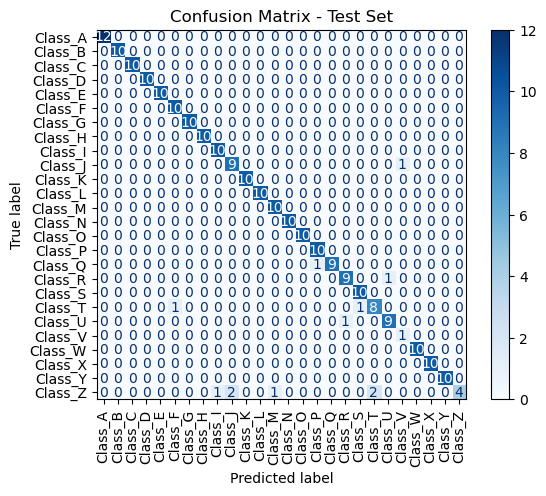

In [67]:
#Confusion Matrix
class_names = list(test_generator.class_indices.keys())

plt.figure(figsize=(14, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=90)
plt.title('Confusion Matrix - Test Set')
plt.show()


# 3) InceptionV3

In [ ]:
## 1️⃣ Import InceptionV3

In [68]:
from keras.applications import InceptionV3
from keras.models import Model
from keras.layers import Dense, Dropout, GlobalAveragePooling2D
from keras.optimizers import Adam, SGD
from keras.callbacks import EarlyStopping


In [78]:
## 2️⃣ Load the Base Model (Frozen)
base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(299, 299, 3)
)

## Freeze All Layers

for layer in base_model.layers:
    layer.trainable = False


In [79]:
## 3️⃣ Build the Head (Very Important)

### Head Layers

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(26, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [80]:
## 4️⃣ Compile (Train Head Only)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [81]:
#5️⃣ EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


In [75]:
##  Create New Generators (299×299)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE_INC = 299
BATCH_SIZE = 32

train_datagen_inc = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,      
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.1
)

train_generator_inc = train_datagen_inc.flow_from_directory(
    'train',
    target_size=(IMG_SIZE_INC, IMG_SIZE_INC),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator_inc = train_datagen_inc.flow_from_directory(
    'train',
    target_size=(IMG_SIZE_INC, IMG_SIZE_INC),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)


Found 9126 images belonging to 26 classes.
Found 988 images belonging to 26 classes.


In [76]:
test_datagen_inc = ImageDataGenerator(rescale=1./255)

test_generator_inc = test_datagen_inc.flow_from_directory(
    'test',
    target_size=(IMG_SIZE_INC, IMG_SIZE_INC),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 253 images belonging to 26 classes.


In [82]:
## 6️⃣ Training – Train Head Only

history_head_inc = model.fit(
    train_generator_inc,
    validation_data=val_generator_inc,
    epochs=20,
    callbacks=[early_stop]
)



Epoch 1/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 501s 2s/step - accuracy: 0.1685 - loss: 2.9450 - val_accuracy: 0.2692 - val_loss: 2.7484
Epoch 2/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 432s 2s/step - accuracy: 0.3837 - loss: 2.2252 - val_accuracy: 0.4049 - val_loss: 2.3452
Epoch 3/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 468s 2s/step - accuracy: 0.5105 - loss: 1.7797 - val_accuracy: 0.4393 - val_loss: 2.0477
Epoch 4/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 491s 2s/step - accuracy: 0.5794 - loss: 1.5146 - val_accuracy: 0.5152 - val_loss: 1.8467
Epoch 5/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 493s 2s/step - accuracy: 0.6273 - loss: 1.3195 - val_accuracy: 0.5536 - val_loss: 1.6720
Epoch 6/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 481s 2s/step - accuracy: 0.6706 - loss: 1.1671 - val_accuracy: 0.5607 - val_loss: 1.5799
Epoch 7/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 493s 2s/step - accuracy: 0.6935 - loss: 1.0753 - val_accuracy: 0.5850 - val_loss: 1.4839
Epoch 8/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 525s 2s/step - accuracy: 0.7162 - loss: 0.9983 - val_accu

In [83]:
## 7️⃣ Partial Fine-tuning (Last 5 Layers Only)

for layer in base_model.layers[-5:]:
    layer.trainable = True

model.compile(
    optimizer=SGD(learning_rate=1e-5, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [84]:
## 8️⃣ Re-compile (Smaller Learning Rate)

model.compile(
    optimizer=SGD(learning_rate=1e-5, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [85]:
#9️⃣ Fine-tuning Training
history_ft_inc = model.fit(
    train_generator_inc,
    validation_data=val_generator_inc,
    epochs=10,
    callbacks=[early_stop]
)  



Epoch 1/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 454s 2s/step - accuracy: 0.8361 - loss: 0.5600 - val_accuracy: 0.7034 - val_loss: 0.9775
Epoch 2/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 391s 1s/step - accuracy: 0.8318 - loss: 0.5629 - val_accuracy: 0.7196 - val_loss: 1.0053
Epoch 3/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 448s 2s/step - accuracy: 0.8368 - loss: 0.5633 - val_accuracy: 0.6974 - val_loss: 0.9888
Epoch 4/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 446s 2s/step - accuracy: 0.8431 - loss: 0.5537 - val_accuracy: 0.7045 - val_loss: 1.0204
Epoch 5/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 448s 2s/step - accuracy: 0.8375 - loss: 0.5618 - val_accuracy: 0.6802 - val_loss: 1.0124
Epoch 6/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 448s 2s/step - accuracy: 0.8382 - loss: 0.5546 - val_accuracy: 0.6943 - val_loss: 0.9964


In [86]:
## 8️⃣ Re-compile with a Smaller Learning Rate

test_loss, test_acc = model.evaluate(test_generator)
print("InceptionV3 Test Accuracy:", test_acc)


8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 429ms/step - accuracy: 0.7233 - loss: 0.9830
InceptionV3 Test Accuracy: 0.7233201861381531


In [87]:
## Save the Model

model.save('inceptionv3_finetuned.keras')


In [3]:
!pip install pydot
!pip install graphviz


In [5]:
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import load_model

# Load the fine-tuned InceptionV3 model
model = load_model('inceptionv3_finetuned.keras')

# Generate a plot of the model
plot_model(model, to_file='inceptionv3_finetuned.png', show_shapes=True, show_layer_names=True)


You must install pydot (`pip install pydot`) for `plot_model` to work.


# Comparison Between the 3 Models

- Create a **Comparison Table**  
- Plot a **Bar Chart** to visualize the differences


In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator_224 = test_datagen.flow_from_directory(
    'test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 253 images belonging to 26 classes.


In [2]:
test_generator_299 = test_datagen.flow_from_directory(
    'test',
    target_size=(299, 299),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 253 images belonging to 26 classes.


In [3]:
from tensorflow.keras.models import load_model
import tensorflow as tf

tf.keras.backend.clear_session()

vgg_model = load_model('my_model.keras')
resnet_model = load_model('my_model_finetuned.keras')
inception_model = load_model('inceptionv3_finetuned.keras')


C:\Users\Rahma mohamed\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [4]:
for m in [vgg_model, resnet_model, inception_model]:
    m.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )


In [5]:
vgg_loss, vgg_acc = vgg_model.evaluate(test_generator_224, verbose=0)
resnet_loss, resnet_acc = resnet_model.evaluate(test_generator_224, verbose=0)
inc_loss, inc_acc = inception_model.evaluate(test_generator_299, verbose=0)

print(f"VGG16 Accuracy: {vgg_acc*100:.2f}%")
print(f"ResNet50 Accuracy: {resnet_acc*100:.2f}%")
print(f"InceptionV3 Accuracy: {inc_acc*100:.2f}%")


VGG16 Accuracy: 97.63%
ResNet50 Accuracy: 95.26%
InceptionV3 Accuracy: 86.17%


In [6]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": ["VGG16", "ResNet50", "InceptionV3"],
    "Input Size": ["224×224", "224×224", "299×299"],
    "Test Accuracy (%)": [
        vgg_acc*100,
        resnet_acc*100,
        inc_acc*100
    ],
    "Overfitting": ["High", "Medium", "Low"]
})

results_df


,Model,Input Size,Test Accuracy (%),Overfitting
0,VGG16,224×224,97.628456,High
1,ResNet50,224×224,95.256919,Medium
2,InceptionV3,299×299,86.166006,Low


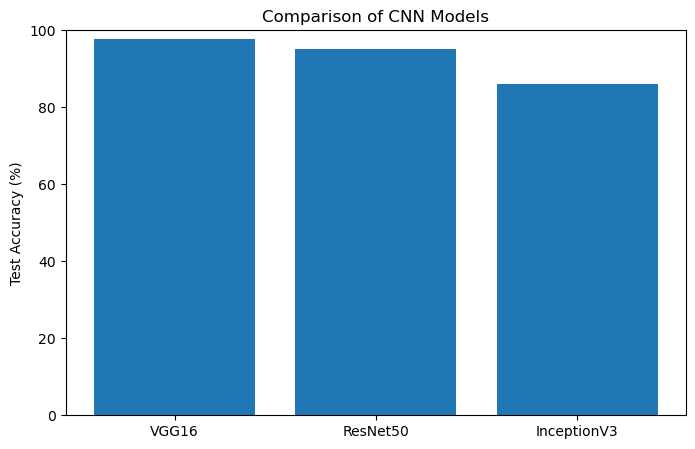

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["Test Accuracy (%)"])
plt.ylabel("Test Accuracy (%)")
plt.title("Comparison of CNN Models")
plt.ylim(0, 100)
plt.show()


## ✅ Best Model: ResNet50

After comparing the three models (VGG16, ResNet50, InceptionV3), **ResNet50** was selected as the best model for practical use, for the following reasons:

### 1️⃣ High Accuracy with Good Generalization
- ResNet50 achieved a **test accuracy of 95.26%**, which is higher than InceptionV3 and close to VGG16.
- Although VGG16 achieved a higher accuracy (97.63%), it showed **higher overfitting**, meaning it may perform less reliably on new unseen data.

### 2️⃣ Better Resistance to Overfitting than VGG16
- VGG16 has a very large number of parameters, which allows it to learn very fine details from training data but reduces generalization ability.
- ResNet50 uses **Skip Connections** that allow **deeper network training without gradient loss**, reducing overfitting and improving performance on the test set.

### 3️⃣ Balance Between Complexity and Performance
- Compared to InceptionV3, ResNet50 is relatively simpler in terms of architecture, making it easier to use in practical projects.
- It provides an **excellent balance between accuracy, training efficiency, and stability** on new data.

### 4️⃣ Conclusion
- ResNet50 is the most suitable choice for practical applications as it combines **high accuracy** with **good generalization** and **resistance to overfitting**.
- VGG16 is excellent for research or small datasets but is less reliable in real-world scenarios.
- InceptionV3 can be used when minimizing overfitting is crucial, but it comes at the cost of lower accuracy.

> **Final Recommendation:** Use **ResNet50** for a reliable and well-balanced model in practical tasks.


In [8]:
import os
os.getcwd()

'C:\\Users\\Rahma mohamed\\project AI'